# Model-3 ConvNext Small 



In [1]:
import os
import time
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision import datasets, models
from IPython.display import display
from torchinfo import summary
import sys
sys.path.append("..")
from utils.metrics import evaluate_model,compare_splits

SEED = 67
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [ ]:
DATA_PATH = "../dataset/processed"
MODEL_PATH = "../models"

os.makedirs(MODEL_PATH, exist_ok=True)

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10
LR = 1e-4

# Loading Data

In [3]:
transform = transforms.Compose([transforms.Resize((IMG_SIZE,IMG_SIZE)),transforms.ToTensor()])

train_data = datasets.ImageFolder(os.path.join(DATA_PATH, "train"),transform=transform)
val_data = datasets.ImageFolder(os.path.join(DATA_PATH, "val"),transform=transform)
test_data = datasets.ImageFolder(os.path.join(DATA_PATH, "test"),transform=transform)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

NUM_CLASSES = len(train_data.classes)
print("Classes:", NUM_CLASSES)

Classes: 38


# Loading Model

In [4]:
model = models.convnext_small(weights="IMAGENET1K_V1")

for param in model.parameters():
    param.requires_grad = False

in_features = model.classifier[2].in_features
model.classifier[2] = nn.Linear(in_features,NUM_CLASSES)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),lr=LR)

In [5]:
print(model)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nTotal params: {total_params:,}")
print(f"Trainable params: {trainable_params:,}")
print(f"Non Trainable params: {total_params-trainable_params:,}")


ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=96, out_features=384, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=384, out_features=96, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=

# Model Training

In [6]:
print("\n" + "="*60)
print("\t\t    TRAINING STARTED")
print("="*60 + "\n")
total_time=0

for epoch in range(EPOCHS):
    start = time.time()
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    val_metrics = evaluate_model(model,val_loader,device,show=False)
    val_acc = val_metrics["Accuracy"]
    t = time.time() - start
    total_time+=t

    print(
        f"[Epoch {epoch+1:02d}/{EPOCHS}] "
        f"Loss={avg_loss:.4f}  "
        f"ValAcc={val_acc:.4f}  "
        f"Time={t:.2f}s"
    )

print("\n Training Finished \n")
print(f"Total Time Taken : {total_time:.2f}s")
print(f"Average Time Taken per epoch : {(total_time/EPOCHS):.2f}s")


		    TRAINING STARTED

[Epoch 01/10] Loss=1.9515  ValAcc=0.8333  Time=448.01s
[Epoch 02/10] Loss=0.8998  ValAcc=0.8813  Time=415.70s
[Epoch 03/10] Loss=0.6209  ValAcc=0.9066  Time=419.32s
[Epoch 04/10] Loss=0.4895  ValAcc=0.9194  Time=414.77s
[Epoch 05/10] Loss=0.4111  ValAcc=0.9320  Time=416.81s
[Epoch 06/10] Loss=0.3605  ValAcc=0.9402  Time=417.79s
[Epoch 07/10] Loss=0.3246  ValAcc=0.9427  Time=483.52s
[Epoch 08/10] Loss=0.2976  ValAcc=0.9475  Time=459.74s
[Epoch 09/10] Loss=0.2762  ValAcc=0.9516  Time=401.36s
[Epoch 10/10] Loss=0.2585  ValAcc=0.9550  Time=404.52s

 Training Finished 

Total Time Taken : 4281.55s
Average Time Taken per epoch : 428.15s


In [7]:
model_file = os.path.join(MODEL_PATH,"convnext_small.pth")
torch.save(model.state_dict(),model_file)
print("Model Saved :", model_file)

Model Saved : ../models/convnext_small.pth


# Model Evaluation

TRAINING DATA


===== METRICS =====


Metrics,Value
Accuracy,0.956732
Precision,0.956523
Recall,0.956702
F1_Score,0.956278
ROC_AUC,0.999362
Log_loss,0.193101



============================ CONFUSION MATRIX =============================


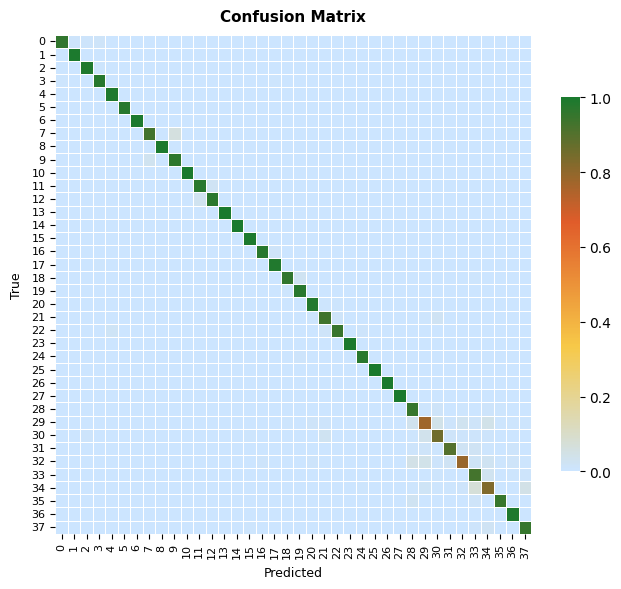


==================================== ROC CURVE ====================================


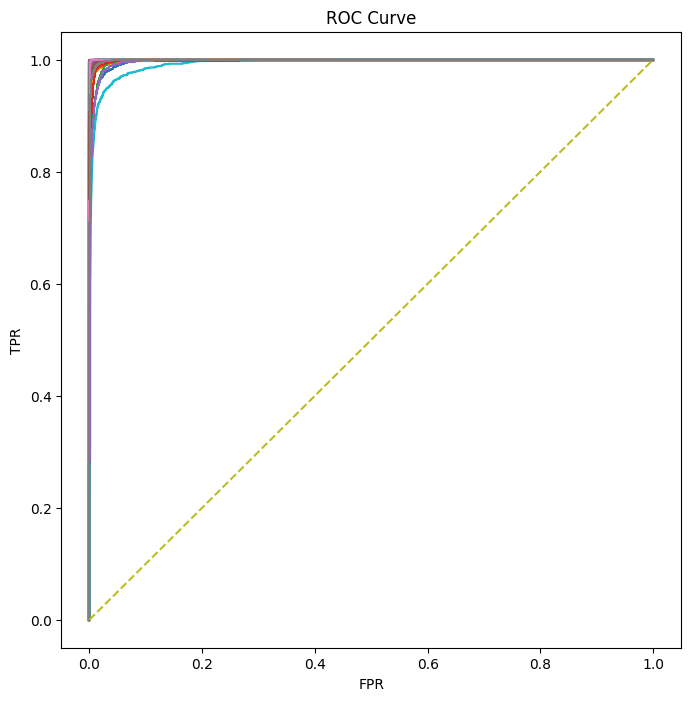

In [8]:
print("TRAINING DATA\n")
train_metrics = evaluate_model(model,train_loader,device)

VALIDATION DATA


===== METRICS =====


Metrics,Value
Accuracy,0.955023
Precision,0.954768
Recall,0.955046
F1_Score,0.954492
ROC_AUC,0.999238
Log_loss,0.204672



============================ CONFUSION MATRIX =============================


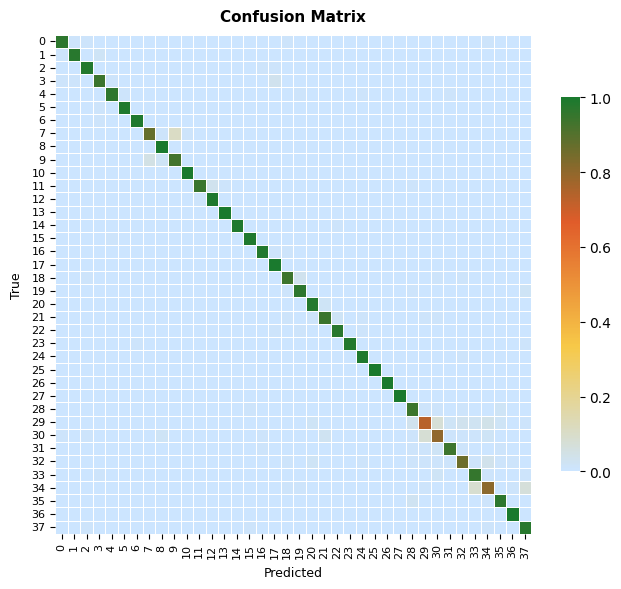


==================================== ROC CURVE ====================================


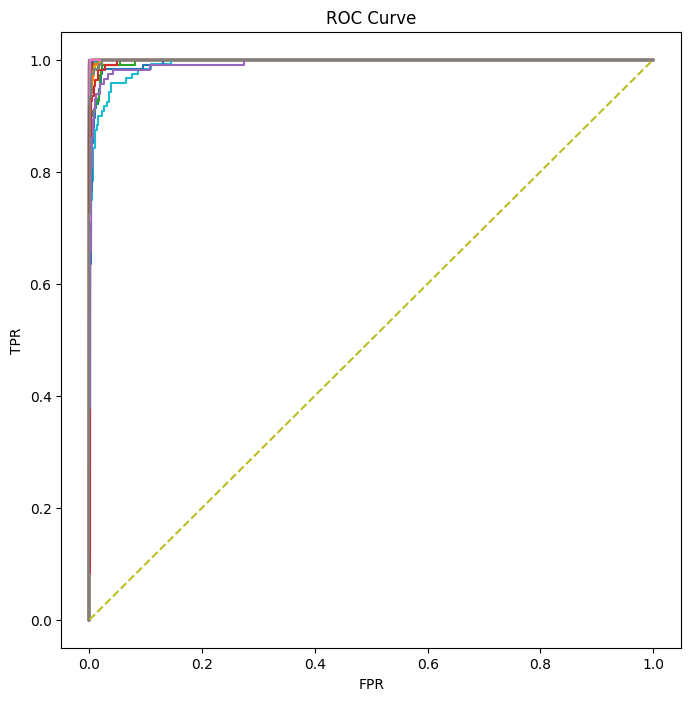

In [9]:
print("VALIDATION DATA\n")
val_metrics = evaluate_model(model,val_loader,device)

TESTING DATA


===== METRICS =====


Metrics,Value
Accuracy,0.954251
Precision,0.954269
Recall,0.954133
F1_Score,0.953858
ROC_AUC,0.999271
Log_loss,0.201794



============================ CONFUSION MATRIX =============================


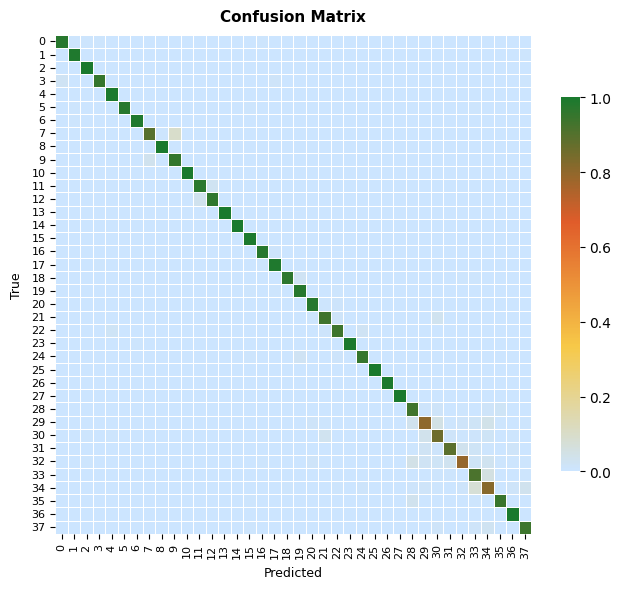


==================================== ROC CURVE ====================================


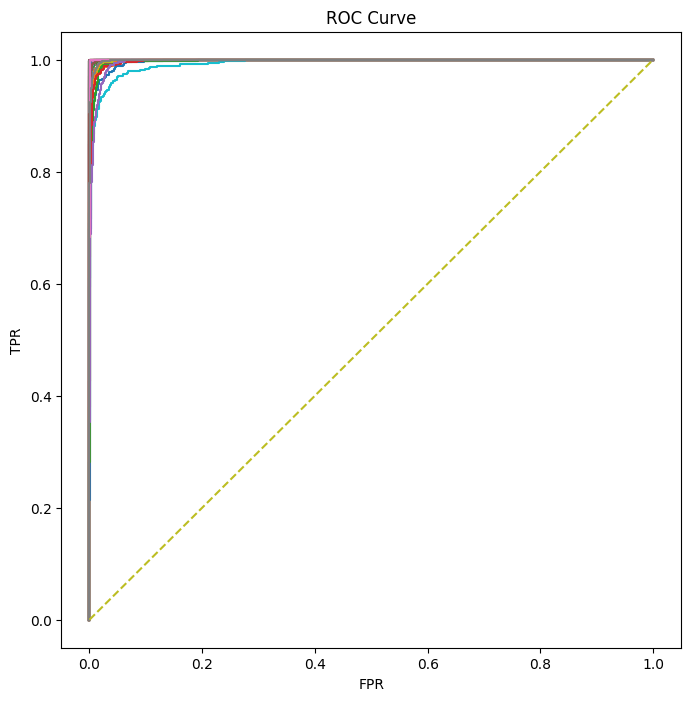

In [10]:
print("TESTING DATA\n")
test_metrics = evaluate_model(model,test_loader,device)


================ SPLIT COMPARISON ================


,Accuracy,Precision,Recall,F1_Score,ROC_AUC,Log_loss
train,0.9567,0.9565,0.9567,0.9563,0.9994,0.1931
val,0.9550,0.9548,0.9550,0.9545,0.9992,0.2047
test,0.9543,0.9543,0.9541,0.9539,0.9993,0.2018


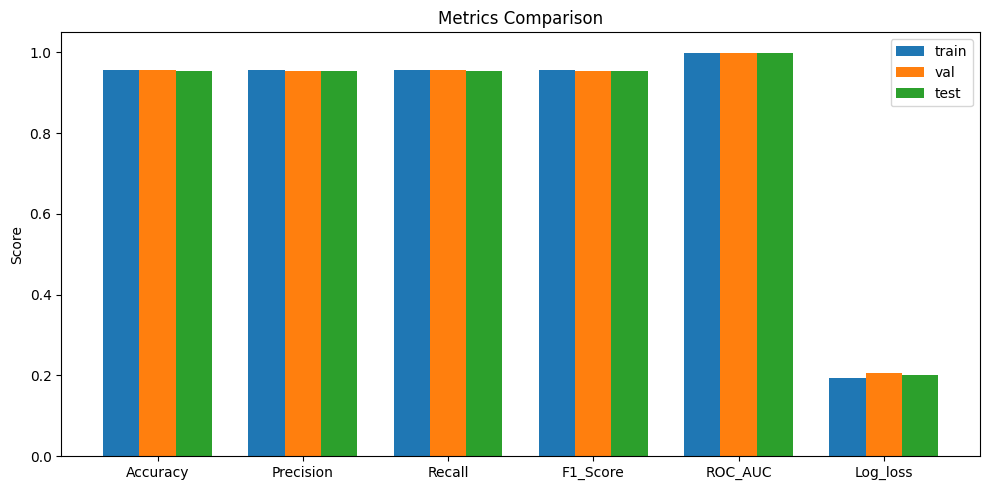

In [11]:
df_comparison=compare_splits(train_metrics,val_metrics,test_metrics)